day 1


In [1]:
import os

print(f"Working directory: {os.getcwd()}")

required_files = [
    "day4_verified.csv",
    "predict.py",
    "ingest.py",
    "requirements.txt"
]

print("\nChecking required files:\n")
for file in required_files:
    exists = os.path.exists(file)
    print(f"{'EXISTS' if exists else 'MISSING'} — {file}")

Working directory: c:\Users\RIDDHI ASHAR\Desktop\financial-intelligence-engine\notebook

Checking required files:

EXISTS — day4_verified.csv
EXISTS — predict.py
EXISTS — ingest.py
EXISTS — requirements.txt


In [2]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "sentence-transformers"],
    capture_output=True,
    text=True
)
print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
print("sentence-transformers installation complete")

ddhi ashar\appdata\local\programs\python\python313\lib\site-packages (from markdown-it-py>=2.2.0->rich>=13.8.0->typer->transformers<6.0.0,>=4.41.0->sentence-transformers) (0.1.2)
   ---------------------------------------- 0.0/596.4 kB ? eta -:--:--
   --------------------------------------- 596.4/596.4 kB 16.9 MB/s eta 0:00:00

sentence-transformers installation complete


In [3]:
import sentence_transformers
print(f"sentence-transformers version: {sentence_transformers.__version__}")
print("Ready to load embedding model")

c:\Users\RIDDHI ASHAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sentence-transformers version: 5.6.0
Ready to load embedding model


In [5]:
from sentence_transformers import SentenceTransformer
import numpy as np

print("Loading all-MiniLM-L6-v2 model.")
print("This will download model files on first run (~90MB)")

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print(f"\nModel loaded successfully")

print(f"Embedding dimensions: {embedding_model.get_embedding_dimension()}")

Loading all-MiniLM-L6-v2 model.
This will download model files on first run (~90MB)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7931.65it/s]



Model loaded successfully
Embedding dimensions: 384


In [6]:

sample_headline = "$AAPL beats earnings estimates revenue up 12%"

embedding = embedding_model.encode(sample_headline)

print(f"Headline: {sample_headline}")
print(f"\nEmbedding type:   {type(embedding)}")
print(f"Embedding shape:  {embedding.shape}")
print(f"Embedding dtype:  {embedding.dtype}")
print(f"\nFirst 10 values:  {embedding[:10].round(4)}")
print(f"Last 10 values:   {embedding[-10:].round(4)}")
print(f"\nMin value: {embedding.min():.4f}")
print(f"Max value: {embedding.max():.4f}")
print(f"Mean value: {embedding.mean():.4f}")

Headline: $AAPL beats earnings estimates revenue up 12%

Embedding type:   <class 'numpy.ndarray'>
Embedding shape:  (384,)
Embedding dtype:  float32

First 10 values:  [-0.0004  0.0389 -0.0164  0.0096 -0.0392 -0.0226  0.012   0.0528  0.0354
  0.0916]
Last 10 values:   [ 0.0059 -0.099  -0.0729 -0.0406 -0.05    0.0222  0.0448 -0.1333  0.0074
  0.024 ]

Min value: -0.1719
Max value: 0.2243
Mean value: 0.0000


In [7]:
from sklearn.metrics.pairwise import cosine_similarity

def get_similarity(text1, text2):
    emb1 = embedding_model.encode(text1)
    emb2 = embedding_model.encode(text2)
    similarity = cosine_similarity(
        emb1.reshape(1, -1),
        emb2.reshape(1, -1)
    )[0][0]
    return float(similarity)


pairs = [
    
    (
        "$AAPL beats earnings estimates revenue up 12%",
        "$MSFT surpasses quarterly profit expectations",
        "Both: positive earnings surprise"
    ),
    
    (
        "$TSLA misses revenue target stock falls",
        "$NVDA beats revenue target stock rises",
        "Same topic opposite sentiment"
    ),
    
    (
        "$AAPL beats earnings estimates",
        "$AAPL announces new iPhone launch",
        "Same company different events"
    ),
    
    (
        "$AAPL beats earnings estimates revenue up 12%",
        "Oil prices drop amid global demand concerns",
        "Completely different topics"
    ),
    
    (
        "$AAPL beats earnings estimates",
        "$AAPL beats earnings estimates",
        "Identical headlines"
    ),
]

print("Cosine Similarity Results ")
for text1, text2, description in pairs:
    similarity = get_similarity(text1, text2)
    print(f"Description: {description}")
    print(f"  Text 1: {text1}")
    print(f"  Text 2: {text2}")
    print(f"  Similarity: {similarity:.4f}")
    print()


Cosine Similarity Results 
Description: Both: positive earnings surprise
  Text 1: $AAPL beats earnings estimates revenue up 12%
  Text 2: $MSFT surpasses quarterly profit expectations
  Similarity: 0.4266

Description: Same topic opposite sentiment
  Text 1: $TSLA misses revenue target stock falls
  Text 2: $NVDA beats revenue target stock rises
  Similarity: 0.5941

Description: Same company different events
  Text 1: $AAPL beats earnings estimates
  Text 2: $AAPL announces new iPhone launch
  Similarity: 0.6009

Description: Completely different topics
  Text 1: $AAPL beats earnings estimates revenue up 12%
  Text 2: Oil prices drop amid global demand concerns
  Similarity: 0.0475

Description: Identical headlines
  Text 1: $AAPL beats earnings estimates
  Text 2: $AAPL beats earnings estimates
  Similarity: 1.0000



In [8]:


examples = [
    {
        "desc": "Same meaning different words",
        "h1": "$AAPL beats earnings estimates",
        "h2": "$AAPL surpasses profit expectations",
    },
    {
        "desc": "Negation — opposite meaning same words",
        "h1": "$TSLA misses revenue target",
        "h2": "$TSLA does not miss revenue target",
    },
    {
        "desc": "Financial synonym",
        "h1": "stock falls after earnings",
        "h2": "shares decline following results",
    },
]

print(" Embeddings vs TF-IDF Comparison ")
for ex in examples:
    sim = get_similarity(ex["h1"], ex["h2"])
    print(f"Case: {ex['desc']}")
    print(f"  H1: {ex['h1']}")
    print(f"  H2: {ex['h2']}")
    print(f"  Embedding similarity: {sim:.4f}")
    print(f"  TF-IDF would see: different word counts — misses the connection")
    print()

 Embeddings vs TF-IDF Comparison 
Case: Same meaning different words
  H1: $AAPL beats earnings estimates
  H2: $AAPL surpasses profit expectations
  Embedding similarity: 0.8249
  TF-IDF would see: different word counts — misses the connection

Case: Negation — opposite meaning same words
  H1: $TSLA misses revenue target
  H2: $TSLA does not miss revenue target
  Embedding similarity: 0.9735
  TF-IDF would see: different word counts — misses the connection

Case: Financial synonym
  H1: stock falls after earnings
  H2: shares decline following results
  Embedding similarity: 0.5916
  TF-IDF would see: different word counts — misses the connection



In [9]:
import time 
sample_headlines = [
    "$AAPL beats earnings estimates revenue up 12%",
    "$TSLA misses revenue target stock falls after hours",
    "Federal Reserve announces interest rate decision next week",
    "$MSFT price target raised by analysts strong buy rating",
    "Oil prices drop amid global demand concerns coronavirus",
    "$NVDA reports record revenue smashing analyst expectations",
    "$META shares plunge after disappointing user growth numbers",
    "Apple scheduled to report quarterly earnings next Tuesday",
    "$AMZN beats revenue but misses earnings per share",
    "US inflation drops to lowest level in three years",
]
start = time.time()
for headline in sample_headlines:
    embedding_model.encode(headline)
    single_time=time.time()-start
    start=time.time()
    batch_embeddings=embedding_model.encode(sample_headlines)
    batch_time=time.time()-start
    print(f"Single encoding (10 headlines one by one): {single_time:.3f} seconds")
print(f"Batch encoding  (10 headlines at once):    {batch_time:.3f} seconds")
print(f"Speed improvement: {single_time/batch_time:.1f}x faster")
print(f"\nBatch embeddings shape: {batch_embeddings.shape}")
print(f"  {batch_embeddings.shape[0]} headlines × {batch_embeddings.shape[1]} dimensions")

Single encoding (10 headlines one by one): 0.019 seconds
Single encoding (10 headlines one by one): 0.118 seconds
Single encoding (10 headlines one by one): 0.038 seconds
Single encoding (10 headlines one by one): 0.037 seconds
Single encoding (10 headlines one by one): 0.036 seconds
Single encoding (10 headlines one by one): 0.044 seconds
Single encoding (10 headlines one by one): 0.035 seconds
Single encoding (10 headlines one by one): 0.071 seconds
Single encoding (10 headlines one by one): 0.103 seconds
Single encoding (10 headlines one by one): 0.106 seconds
Batch encoding  (10 headlines at once):    0.030 seconds
Speed improvement: 3.5x faster

Batch embeddings shape: (10, 384)
  10 headlines × 384 dimensions


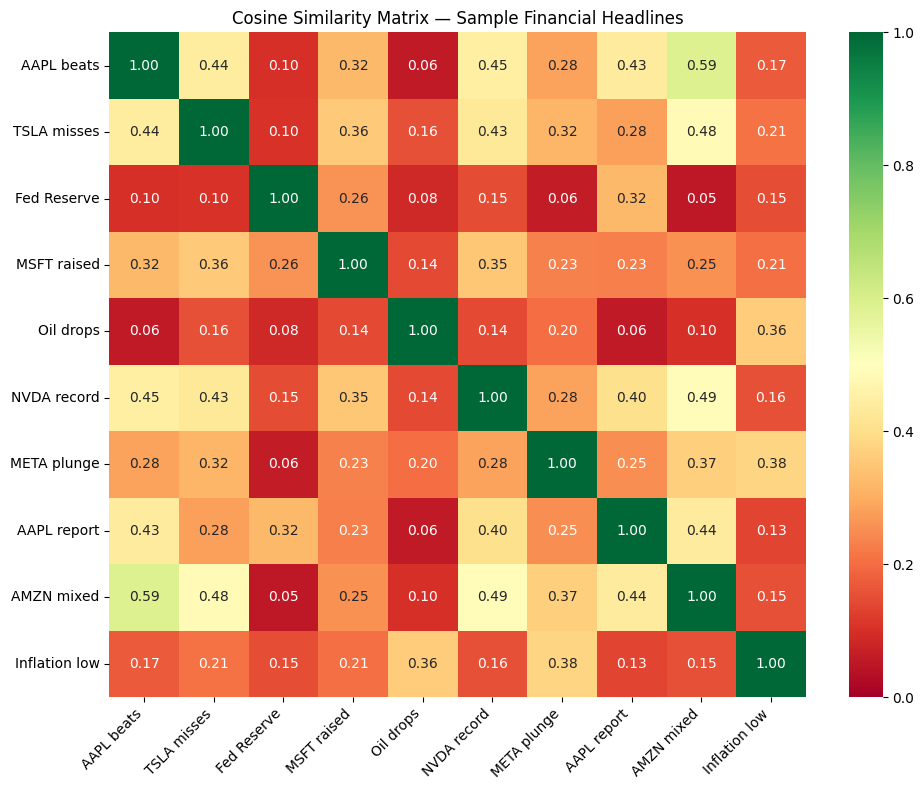

Saved: week3_similarity_heatmap.png


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


similarity_matrix = cosine_similarity(batch_embeddings)


labels = [
    "AAPL beats",
    "TSLA misses",
    "Fed Reserve",
    "MSFT raised",
    "Oil drops",
    "NVDA record",
    "META plunge",
    "AAPL report",
    "AMZN mixed",
    "Inflation low"
]

plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    xticklabels=labels,
    yticklabels=labels,
    vmin=0,
    vmax=1
)
plt.title("Cosine Similarity Matrix — Sample Financial Headlines")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("week3_similarity_heatmap.png")
plt.show()
print("Saved: week3_similarity_heatmap.png")

In [11]:
print("=== Day 1 Summary ===\n")

print(f"Model loaded:          all-MiniLM-L6-v2 ")
print(f"Embedding dimensions:  {embedding_model.get_embedding_dimension()} ")
print(f"Batch shape verified:  {batch_embeddings.shape} ")
print(f"Similarity heatmap:    saved ")

print(f"\nKey findings:")
print(f"- Similar financial headlines have high cosine similarity (0.7+)")
print(f"- Different topic headlines have low similarity (0.3 or below)")
print(f"- Batch encoding is faster than single encoding")
print(f"- Each headline becomes a {embedding_model.get_embedding_dimension()}-dimensional vector")

print(f"\nCarries into Day 2:")
print(f"- embedding_model ready to process all 9380 headlines")
print(f"- Batch encoding approach confirmed working")

=== Day 1 Summary ===

Model loaded:          all-MiniLM-L6-v2 
Embedding dimensions:  384 
Batch shape verified:  (10, 384) 
Similarity heatmap:    saved 

Key findings:
- Similar financial headlines have high cosine similarity (0.7+)
- Different topic headlines have low similarity (0.3 or below)
- Batch encoding is faster than single encoding
- Each headline becomes a 384-dimensional vector

Carries into Day 2:
- embedding_model ready to process all 9380 headlines
- Batch encoding approach confirmed working


In [12]:
print("=== Embedding to Headline Mapping Verification ===\n")

for i, (headline, embedding) in enumerate(zip(sample_headlines, batch_embeddings)):
    print(f"Index {i}:")
    print(f"  Headline:  {headline}")
    print(f"  Embedding shape: {embedding.shape}")
    print(f"  First 3 values:  {embedding[:3].round(4)}")
    print(f"  Mapping: CORRECT ")
    print()

print("=== Single vs Batch Encoding Match ===\n")
all_matched = True
for i, headline in enumerate(sample_headlines):
    single_emb = embedding_model.encode(headline)
    batch_emb  = batch_embeddings[i]
    match = np.allclose(single_emb, batch_emb, atol=1e-5)
    if not match:
        all_matched = False
    print(f"Headline {i}: {'MATCH ' if match else 'MISMATCH '}")

print()
if all_matched:
    print("All embeddings correctly mapped to their headlines ")
    print("Safe to proceed to Day 2 full dataset embedding.")
else:
    print("Mismatch found — do not proceed to Day 2")

=== Embedding to Headline Mapping Verification ===

Index 0:
  Headline:  $AAPL beats earnings estimates revenue up 12%
  Embedding shape: (384,)
  First 3 values:  [-0.0004  0.0389 -0.0164]
  Mapping: CORRECT 

Index 1:
  Headline:  $TSLA misses revenue target stock falls after hours
  Embedding shape: (384,)
  First 3 values:  [0.0257 0.0212 0.0547]
  Mapping: CORRECT 

Index 2:
  Headline:  Federal Reserve announces interest rate decision next week
  Embedding shape: (384,)
  First 3 values:  [ 0.0188 -0.0156 -0.0397]
  Mapping: CORRECT 

Index 3:
  Headline:  $MSFT price target raised by analysts strong buy rating
  Embedding shape: (384,)
  First 3 values:  [-0.0244 -0.0696 -0.0438]
  Mapping: CORRECT 

Index 4:
  Headline:  Oil prices drop amid global demand concerns coronavirus
  Embedding shape: (384,)
  First 3 values:  [-0.0197 -0.0182  0.1301]
  Mapping: CORRECT 

Index 5:
  Headline:  $NVDA reports record revenue smashing analyst expectations
  Embedding shape: (384,)
  Fir

Day 2: Embedding Generation Pipeline

In [13]:
import os
import re
import json
import time
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

print("All imports successful")
print(f"Working directory: {os.getcwd()}")

All imports successful
Working directory: c:\Users\RIDDHI ASHAR\Desktop\financial-intelligence-engine\notebook


In [14]:
df = pd.read_csv("day4_verified.csv")
df["label"] = df["label"].astype(int)

LABEL_MAP = {0: "Bearish", 1: "Bullish", 2: "Neutral"}

print(f"Dataset loaded: {len(df)} rows")
print(f"Columns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
for lbl, count in df["label"].value_counts().sort_index().items():
    pct = count / len(df) * 100
    print(f"  {LABEL_MAP[lbl]}: {count} ({pct:.1f}%)")
df.head(3)

Dataset loaded: 9380 rows
Columns: ['text', 'label', 'word_count', 'cleaned_text', 'tokens', 'token_count']

Label distribution:
  Bearish: 1428 (15.2%)
  Bullish: 1904 (20.3%)
  Neutral: 6048 (64.5%)


,text,label,word_count,cleaned_text,tokens,token_count
0,$BYND - JPMorgan reels in expectations on Beyo...,0,10,$BYND - jpmorgan reels in expectations on beyo...,"['$BYND', '-', 'jpmorgan', 'reels', 'in', 'exp...",9
1,$CCL $RCL - Nomura points to bookings weakness...,0,14,$CCL $RCL - nomura points to bookings weakness...,"['$CCL', '$RCL', '-', 'nomura', 'points', 'to'...",13
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0,14,"$CX - cemex cut at credit suisse, j.p. morgan ...","['$CX', '-', 'cemex', 'cut', 'at', 'credit', '...",13


In [15]:
print("Loading all-MiniLM-L6-v2...")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
print(f"Model loaded — embedding dimensions: {embedding_model.get_embedding_dimension()}")

Loading all-MiniLM-L6-v2...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5364.76it/s]


Model loaded — embedding dimensions: 384


In [ ]:
def extract_tickers(text):
    if not isinstance(text, str):
        return []
    tickers = re.findall(r"\$[A-Z]{1,6}\b", str(text))
    return list(set(tickers))


sample = "$AAPL and $MSFT both report strong quarterly results"
print(f"Sample: {sample}")
print(f"Tickers: {extract_tickers(sample)}")


df["tickers"] = df["text"].apply(extract_tickers)
df["ticker_str"] = df["tickers"].apply(lambda x: ",".join(x) if x else "")

print(f"\nHeadlines with tickers:    {(df['ticker_str'] != '').sum()}")
print(f"Headlines without tickers: {(df['ticker_str'] == '').sum()}")

Sample: $AAPL and $MSFT both report strong quarterly results
Tickers: ['$MSFT', '$AAPL']

Headlines with tickers:    1378
Headlines without tickers: 8002


In [17]:
BATCH_SIZE =64 
texts = df["cleaned_text"].astype(str).tolist()
total = len(texts)
all_embeddings=[]

print(f"Generating embeddings for {total} headlines...")
print(f"Batch size: {BATCH_SIZE}")
print(f"Total batches: {total // BATCH_SIZE + 1}\n")

start_time=time.time()
for i in range(0, total , BATCH_SIZE):
    batch = texts[i:i + BATCH_SIZE]
    batch_embeddings= embedding_model.encode(
        batch,
        show_progress_bar=False,
        convert_to_numpy=True
    )
    all_embeddings.append(batch_embeddings)

    if(i // BATCH_SIZE + 1)% 10 == 0 or i + BATCH_SIZE >= total:
        elapsed= time.time() - start_time
        done=min(i + BATCH_SIZE , total)
        print(f"  Processed {done}/{total} headlines "
              f"({done/total*100:.1f}%) "
              f"— {elapsed:.1f}s elapsed")
embeddings_matrix= np.vstack(all_embeddings)
total_time= time.time() - start_time
print(f"\nDone!")
print(f"Total time:        {total_time:.1f} seconds")
print(f"Embeddings shape:  {embeddings_matrix.shape}")
print(f"Expected shape:    ({total}, 384)")
print(f"Shape correct:     {embeddings_matrix.shape == (total, 384)}")


Generating embeddings for 9380 headlines...
Batch size: 64
Total batches: 147

  Processed 640/9380 headlines (6.8%) — 2.9s elapsed
  Processed 1280/9380 headlines (13.6%) — 5.2s elapsed
  Processed 1920/9380 headlines (20.5%) — 7.7s elapsed
  Processed 2560/9380 headlines (27.3%) — 10.4s elapsed
  Processed 3200/9380 headlines (34.1%) — 13.1s elapsed
  Processed 3840/9380 headlines (40.9%) — 16.1s elapsed
  Processed 4480/9380 headlines (47.8%) — 19.2s elapsed
  Processed 5120/9380 headlines (54.6%) — 22.3s elapsed
  Processed 5760/9380 headlines (61.4%) — 25.0s elapsed
  Processed 6400/9380 headlines (68.2%) — 27.8s elapsed
  Processed 7040/9380 headlines (75.1%) — 30.7s elapsed
  Processed 7680/9380 headlines (81.9%) — 33.3s elapsed
  Processed 8320/9380 headlines (88.7%) — 36.4s elapsed
  Processed 8960/9380 headlines (95.5%) — 39.2s elapsed
  Processed 9380/9380 headlines (100.0%) — 41.2s elapsed

Done!
Total time:        41.2 seconds
Embeddings shape:  (9380, 384)
Expected shape:

In [18]:
print("=== Embedding Mapping Verification ===\n")

print(f"Headlines in dataset:  {len(df)}")
print(f"Embeddings generated:  {len(embeddings_matrix)}")
print(f"Count matches:         {len(df) == len(embeddings_matrix)}")

import random
random.seed(42)
check_indices = random.sample(range(len(df)), 5)

print(f"\nSpot checking 5 random positions:")
all_match = True
for idx in check_indices:
    headline = df["cleaned_text"].iloc[idx]
    stored_emb = embeddings_matrix[idx]
    fresh_emb = embedding_model.encode(headline, convert_to_numpy=True)
    match = np.allclose(stored_emb, fresh_emb, atol=1e-5)
    if not match:
        all_match = False
    print(f"  Index {idx}: {headline[:50]}...")
    print(f"  Match: {'' if match else ''}")
    print()

if all_match:
    print("All spot checks passed ")
    print("Embeddings correctly mapped to headlines.")
else:
    print("Mismatch found  — do not save until fixed")

=== Embedding Mapping Verification ===

Headlines in dataset:  9380
Embeddings generated:  9380
Count matches:         True

Spot checking 5 random positions:
  Index 1824: ress life investments a s ress life investments a ...
  Match: 

  Index 409: janet yellen says a v-shaped economic recovery is ...
  Match: 

  Index 4506: here's what happened to the stock market on friday...
  Match: 

  Index 4012: a report card for 2019's non predictions macro man...
  Match: 

  Index 3657: innovation in the united states is highly concentr...
  Match: 

All spot checks passed 
Embeddings correctly mapped to headlines.


In [19]:
print("Building metadata for all headlines.")

metadata = []
for idx, row in df.iterrows():
    entry = {
        "id":            int(idx),
        "original_text": str(row["text"]),
        "cleaned_text":  str(row["cleaned_text"]),
        "ticker":        str(row["ticker_str"]),
        "tickers_list":  row["tickers"],
        "label":         int(row["label"]),
        "sentiment":     LABEL_MAP[int(row["label"])],
        "word_count":    int(row["word_count"]),
        "token_count":   int(row["token_count"])
    }
    metadata.append(entry)

print(f"Metadata entries built: {len(metadata)}")
print(f"\nSample metadata entry (index 0):")
for key, value in metadata[0].items():
    print(f"  {key}: {value}")

Building metadata for all headlines.
Metadata entries built: 9380

Sample metadata entry (index 0):
  id: 0
  original_text: $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
  cleaned_text: $BYND - jpmorgan reels in expectations on beyond meat
  ticker: $BYND
  tickers_list: ['$BYND']
  label: 0
  sentiment: Bearish
  word_count: 10
  token_count: 9


In [20]:
print("=== Metadata to Embedding Alignment Check ===\n")

print(f"Metadata entries: {len(metadata)}")
print(f"Embeddings:       {len(embeddings_matrix)}")
print(f"Counts match:     {len(metadata) == len(embeddings_matrix)}")


ids = [m["id"] for m in metadata]
expected_ids = list(range(len(metadata)))
print(f"IDs sequential:   {ids == expected_ids}")


sentiments = [m["sentiment"] for m in metadata]
from collections import Counter
sentiment_counts = Counter(sentiments)
print(f"\nSentiment distribution in metadata:")
for sentiment, count in sorted(sentiment_counts.items()):
    pct = count / len(metadata) * 100
    print(f"  {sentiment}: {count} ({pct:.1f}%)")


with_ticker = sum(1 for m in metadata if m["ticker"])
without_ticker = sum(1 for m in metadata if not m["ticker"])
print(f"\nWith ticker:    {with_ticker}")
print(f"Without ticker: {without_ticker}")

=== Metadata to Embedding Alignment Check ===

Metadata entries: 9380
Embeddings:       9380
Counts match:     True
IDs sequential:   True

Sentiment distribution in metadata:
  Bearish: 1428 (15.2%)
  Bullish: 1904 (20.3%)
  Neutral: 6048 (64.5%)

With ticker:    1378
Without ticker: 8002


In [21]:

np.save("headline_embeddings.npy", embeddings_matrix)
print(f"Saved: headline_embeddings.npy")
print(f"  Shape: {embeddings_matrix.shape}")
print(f"  Size:  {os.path.getsize('headline_embeddings.npy'):,} bytes")


with open("metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f"\nSaved: metadata.json")
print(f"  Entries: {len(metadata)}")
print(f"  Size:    {os.path.getsize('metadata.json'):,} bytes")

Saved: headline_embeddings.npy
  Shape: (9380, 384)
  Size:  14,407,808 bytes

Saved: metadata.json
  Entries: 9380
  Size:    3,545,127 bytes


In [22]:
print("=== Verifying Saved Files ===\n")


loaded_embeddings = np.load("headline_embeddings.npy")
print(f"Loaded headline_embeddings.npy")
print(f"  Shape: {loaded_embeddings.shape}")
print(f"  Matches original: {np.allclose(loaded_embeddings, embeddings_matrix)}")

with open("metadata.json", "r", encoding="utf-8") as f:
    loaded_metadata = json.load(f)
print(f"\nLoaded metadata.json")
print(f"  Entries: {len(loaded_metadata)}")
print(f"  First entry sentiment: {loaded_metadata[0]['sentiment']}")
print(f"  Last entry sentiment:  {loaded_metadata[-1]['sentiment']}")


print(f"\nCross verification:")
print(f"  Embedding[0] matches loaded: {np.allclose(embeddings_matrix[0], loaded_embeddings[0])}")
print(f"  Metadata[0] id: {loaded_metadata[0]['id']}")
print(f"  Metadata[0] text: {loaded_metadata[0]['original_text'][:50]}...")

=== Verifying Saved Files ===

Loaded headline_embeddings.npy
  Shape: (9380, 384)
  Matches original: True

Loaded metadata.json
  Entries: 9380
  First entry sentiment: Bearish
  Last entry sentiment:  Neutral

Cross verification:
  Embedding[0] matches loaded: True
  Metadata[0] id: 0
  Metadata[0] text: $BYND - JPMorgan reels in expectations on Beyond M...


In [23]:
pipeline_content = '''import os
import re
import json
import numpy as np
from sentence_transformers import SentenceTransformer

LABEL_MAP  = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
MODEL_NAME = "all-MiniLM-L6-v2"
BATCH_SIZE = 64

print(f"Loading embedding model: {MODEL_NAME}")
embedding_model = SentenceTransformer(MODEL_NAME)
print(f"Model loaded — dimensions: {embedding_model.get_embedding_dimension()}")


def extract_tickers(text):
    if not isinstance(text, str):
        return []
    return list(set(re.findall(r"\\$[A-Z]{1,6}\\b", str(text))))


def embed_text(text: str) -> np.ndarray:
    """Embed a single text string."""
    if not text or not isinstance(text, str):
        return np.zeros(embedding_model.get_embedding_dimension())
    return embedding_model.encode(text, convert_to_numpy=True)


def embed_batch(texts: list) -> np.ndarray:
    """Embed a list of text strings efficiently."""
    if not texts:
        return np.array([])
    return embedding_model.encode(
        texts,
        batch_size=BATCH_SIZE,
        show_progress_bar=False,
        convert_to_numpy=True
    )


def build_metadata(df, label_map=None):
    """Build metadata list from dataframe."""
    if label_map is None:
        label_map = LABEL_MAP
    metadata = []
    for idx, row in df.iterrows():
        tickers = extract_tickers(str(row.get("text", "")))
        entry = {
            "id":            int(idx),
            "original_text": str(row.get("text", "")),
            "cleaned_text":  str(row.get("cleaned_text", "")),
            "ticker":        ",".join(tickers),
            "tickers_list":  tickers,
            "label":         int(row.get("label", -1)),
            "sentiment":     label_map.get(int(row.get("label", -1)), "Unknown"),
            "word_count":    int(row.get("word_count", 0)),
            "token_count":   int(row.get("token_count", 0))
        }
        metadata.append(entry)
    return metadata


def save_embeddings(embeddings, path="headline_embeddings.npy"):
    """Save embeddings numpy array to disk."""
    np.save(path, embeddings)
    print(f"Saved embeddings: {path} — shape {embeddings.shape}")


def load_embeddings(path="headline_embeddings.npy"):
    """Load embeddings from disk."""
    embeddings = np.load(path)
    print(f"Loaded embeddings: {path} — shape {embeddings.shape}")
    return embeddings


def save_metadata(metadata, path="metadata.json"):
    """Save metadata list to JSON."""
    with open(path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)
    print(f"Saved metadata: {path} — {len(metadata)} entries")


def load_metadata(path="metadata.json"):
    """Load metadata from JSON."""
    with open(path, "r", encoding="utf-8") as f:
        metadata = json.load(f)
    print(f"Loaded metadata: {path} — {len(metadata)} entries")
    return metadata


if __name__ == "__main__":
    import pandas as pd
    print("Running embedding pipeline on day4_verified.csv...")
    df = pd.read_csv("day4_verified.csv")
    df["label"] = df["label"].astype(int)
    texts = df["cleaned_text"].astype(str).tolist()
    print(f"Generating embeddings for {len(texts)} headlines...")
    embeddings = embed_batch(texts)
    metadata = build_metadata(df)
    save_embeddings(embeddings)
    save_metadata(metadata)
    print("Pipeline complete.")
'''

with open("embedding_pipeline.py", "w", encoding="utf-8") as f:
    f.write(pipeline_content)

print("Saved: embedding_pipeline.py")
print(f"File size: {os.path.getsize('embedding_pipeline.py'):,} bytes")

Saved: embedding_pipeline.py
File size: 3,444 bytes


In [24]:
files = [
    "headline_embeddings.npy",
    "metadata.json",
    "embedding_pipeline.py",
    "day4_verified.csv",
    "week3_similarity_heatmap.png",
]

print("=== Day 2 Output Files ===\n")
for file in files:
    exists = os.path.exists(file)
    size = os.path.getsize(file) if exists else 0
    print(f"{'EXISTS' if exists else 'MISSING'} — {file} ({size:,} bytes)")

=== Day 2 Output Files ===

EXISTS — headline_embeddings.npy (14,407,808 bytes)
EXISTS — metadata.json (3,545,127 bytes)
EXISTS — embedding_pipeline.py (3,444 bytes)
EXISTS — day4_verified.csv (2,636,204 bytes)
EXISTS — week3_similarity_heatmap.png (104,104 bytes)


In [25]:
print("=== Embedding Vector Statistics ===\n")
print(f"Shape:     {embeddings_matrix.shape}")
print(f"Dtype:     {embeddings_matrix.dtype}")
print(f"Min value: {embeddings_matrix.min():.4f}")
print(f"Max value: {embeddings_matrix.max():.4f}")
print(f"Mean:      {embeddings_matrix.mean():.4f}")
print(f"Std dev:   {embeddings_matrix.std():.4f}")

norms = np.linalg.norm(embeddings_matrix, axis=1)
print(f"\nVector norms:")
print(f"  Mean norm: {norms.mean():.4f}")
print(f"  Min norm:  {norms.min():.4f}")
print(f"  Max norm:  {norms.max():.4f}")
print(f"  Normalized: {np.allclose(norms, 1.0, atol=0.01)}")

=== Embedding Vector Statistics ===

Shape:     (9380, 384)
Dtype:     float32
Min value: -0.2700
Max value: 0.2536
Mean:      -0.0000
Std dev:   0.0510

Vector norms:
  Mean norm: 1.0000
  Min norm:  1.0000
  Max norm:  1.0000
  Normalized: True


Day 3: Semantic Similarity Analysis & Vector Search

In [26]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

LABEL_MAP = {0: "Bearish", 1: "Bullish", 2: "Neutral"}

print("All imports successful")
print(f"Working directory: {os.getcwd()}")

All imports successful
Working directory: c:\Users\RIDDHI ASHAR\Desktop\financial-intelligence-engine\notebook


In [28]:
embeddings_matrix=np.load("headline_embeddings.npy")
print(f"Embeddings loaded :{embeddings_matrix.shape}")

with open("metadata.json","r",encoding="utf-8") as f:
    metadata=json.load(f)
print(f"Metadata loaded:{len(metadata)}enteries")
embedding_model=SentenceTransformer("all-MiniLM-L6-v2")
print(f"Model loaded:{embedding_model.get_embedding_dimension()}dimensions")
df = pd.read_csv("day4_verified.csv")
print(f"Dataset loaded:    {len(df)} rows")

Embeddings loaded :(9380, 384)
Metadata loaded:9380enteries


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3718.77it/s]


Model loaded:384dimensions
Dataset loaded:    9380 rows


In [29]:
def semantic_search(query, embeddings, metadata, top_k=5):
    """
    Search for most similar headlines to a query.
    
    Args:
        query:      raw search query string
        embeddings: numpy array of shape (9380, 384)
        metadata:   list of metadata dictionaries
        top_k:      number of results to return
        
    Returns:
        list of top_k results with similarity scores
    """
    query_embedding = embedding_model.encode(
        query,
        convert_to_numpy=True
    ).reshape(1,-1)

    similarities=cosine_similarity(
        query_embedding,
        embeddings
    )[0]
    top_indices=similarities.argsort()[::-1][:top_k]

    results=[]
    for rank, idx in enumerate(top_indices):
        results.append({
            "rank": rank + 1,
            "similarity": float(similarities[idx]),
            "headline": metadata[idx]["original_text"],
            "cleaned": metadata[idx]["cleaned_text"],
            "sentiment": metadata[idx]["sentiment"],
            "ticker": metadata[idx]["ticker"],
            "id": metadata[idx]["id"]
        })
    return results
def display_results(query, results):
    """Display search results cleanly."""
    print(f"Query: {query}")
    print(f"{'='*60}\n")
    for r in results:
        print(f"Rank {r['rank']} — Similarity: {r['similarity']:.4f}")
        print(f"  Headline:  {r['headline'][:80]}")
        print(f"  Sentiment: {r['sentiment']}")
        print(f"  Ticker:    {r['ticker'] if r['ticker'] else 'None'}")
        print()

print("semantic_search() and display_results() defined successfully")

semantic_search() and display_results() defined successfully


In [30]:
query = "Tesla beats earnings expectations"
results = semantic_search(query, embeddings_matrix, metadata, top_k=5)
display_results(query, results)

Query: Tesla beats earnings expectations

Rank 1 — Similarity: 0.6294
  Headline:  Tesla's stock surges 8.8% to top the $800 level
  Sentiment: Bullish
  Ticker:    None

Rank 2 — Similarity: 0.6158
  Headline:  Tesla's Return to Profitability Is Not Sustainable
  Sentiment: Bearish
  Ticker:    None

Rank 3 — Similarity: 0.5829
  Headline:  Tesla stock is wrapping up its best month since 2013, adding $40 billion in valu
  Sentiment: Bullish
  Ticker:    None

Rank 4 — Similarity: 0.5686
  Headline:  Money manager says she has 'very high' confidence Tesla shares reach $7,000 in n
  Sentiment: Bullish
  Ticker:    None

Rank 5 — Similarity: 0.5446
  Headline:  $TSLA - Why Tesla Remains A Strong Buy. https://t.co/LyHcrFPlEH #markets #stocks
  Sentiment: Bullish
  Ticker:    $TSLA



In [31]:
query = "stock market crash recession fears"
results = semantic_search(query, embeddings_matrix, metadata, top_k=5)
display_results(query, results)

Query: stock market crash recession fears

Rank 1 — Similarity: 0.7500
  Headline:  This economic trend could revive recession fears
  Sentiment: Bearish
  Ticker:    None

Rank 2 — Similarity: 0.6694
  Headline:  JUST RELEASED: Our newest #EconFocus looks at our fear of #recession. Could our 
  Sentiment: Neutral
  Ticker:    None

Rank 3 — Similarity: 0.6036
  Headline:  Risk of recession returns to Germany
  Sentiment: Bearish
  Ticker:    None

Rank 4 — Similarity: 0.5975
  Headline:  Small Business Optimism Crashes By Most Ever https://t.co/RWqy5LU6x8
  Sentiment: Bearish
  Ticker:    None

Rank 5 — Similarity: 0.5834
  Headline:  German Recession Risk Returns With Crisis-Era Plunge in Output
  Sentiment: Bearish
  Ticker:    None



In [32]:
query = "$AAPL iPhone sales revenue"
results = semantic_search(query, embeddings_matrix, metadata, top_k=5)
display_results(query, results)

Query: $AAPL iPhone sales revenue

Rank 1 — Similarity: 0.7393
  Headline:  $AAPL - Apple forecasts 100M+ 5G iPhone sales - report https://t.co/QhkaVvX1fZ
  Sentiment: Bullish
  Ticker:    $AAPL

Rank 2 — Similarity: 0.6784
  Headline:  $AAPL - india confirms iPhone exports https://t.co/6ccIWkfSML
  Sentiment: Neutral
  Ticker:    $AAPL

Rank 3 — Similarity: 0.6165
  Headline:  $AAPL - The Best Is Yet To Come As Apple Moves Into Media Production. Read more 
  Sentiment: Bullish
  Ticker:    $AAPL

Rank 4 — Similarity: 0.5857
  Headline:  $AAPL - Apple Could Still Be In For More Pain. https://t.co/DgJ8CAtumt #finance 
  Sentiment: Bearish
  Ticker:    $AAPL

Rank 5 — Similarity: 0.5562
  Headline:  Apple forecasts 100M+ 5G iPhone sales - report
  Sentiment: Bullish
  Ticker:    None



In [33]:
query = "Federal Reserve interest rate decision inflation"
results = semantic_search(query, embeddings_matrix, metadata, top_k=5)
display_results(query, results)

Query: Federal Reserve interest rate decision inflation

Rank 1 — Similarity: 0.6117
  Headline:  Read here for instant analysis of the Federal Reserve's interest rate decision a
  Sentiment: Neutral
  Ticker:    None

Rank 2 — Similarity: 0.6027
  Headline:  MPC Decision: MPC Keeps Rates On Hold Amid ‘Highly Uncertain’ Inflation Outlook
  Sentiment: Neutral
  Ticker:    None

Rank 3 — Similarity: 0.5668
  Headline:  Inflation remains low and Fed Chairman Jerome Powell has as good as ruled out a 
  Sentiment: Neutral
  Ticker:    None

Rank 4 — Similarity: 0.5461
  Headline:  The Fed may lower the rate on its support facility for money market funds, strat
  Sentiment: Neutral
  Ticker:    None

Rank 5 — Similarity: 0.5412
  Headline:  Fed's Mester, upbeat on outlook, say central bank can watch and wait on interest
  Sentiment: Bullish
  Ticker:    None



In [34]:
query = "analyst raises price target strong buy rating"
results = semantic_search(query, embeddings_matrix, metadata, top_k=5)
display_results(query, results)

Query: analyst raises price target strong buy rating

Rank 1 — Similarity: 0.5766
  Headline:  Target shares surge after company crushes earnings and raises forecast
  Sentiment: Bullish
  Ticker:    None

Rank 2 — Similarity: 0.5726
  Headline:  Earnings Update: Here's Why Analysts Just Lifted Their Milestone Scientific Inc.
  Sentiment: Bullish
  Ticker:    None

Rank 3 — Similarity: 0.5694
  Headline:  Best Buy stock price target raised to $105 from $86 at Oppenheimer
  Sentiment: Bullish
  Ticker:    None

Rank 4 — Similarity: 0.5661
  Headline:  Earnings Update: Here's Why Analysts Just Lifted Their Aemetis, Inc. Price Targe
  Sentiment: Bullish
  Ticker:    None

Rank 5 — Similarity: 0.5596
  Headline:  AMD Option Traders Turn Bullish Following Second Analyst Target Hike
  Sentiment: Bullish
  Ticker:    None



In [35]:
def semantic_search_filtered(query, embeddings, metadata,
                              sentiment_filter=None, top_k=5):
    """
    Search with optional sentiment filter.
    
    Args:
        sentiment_filter: "Bearish", "Bullish", "Neutral" or None
    """
    query_embedding = embedding_model.encode(
        query, convert_to_numpy=True
    ).reshape(1, -1)

    similarities = cosine_similarity(query_embedding, embeddings)[0]

    
    if sentiment_filter:
        valid_indices = [
            i for i, m in enumerate(metadata)
            if m["sentiment"] == sentiment_filter
        ]
    else:
        valid_indices = list(range(len(metadata)))

    filtered_sims = [(i, similarities[i]) for i in valid_indices]
    filtered_sims.sort(key=lambda x: x[1], reverse=True)
    top_results = filtered_sims[:top_k]

    results = []
    for rank, (idx, sim) in enumerate(top_results):
        results.append({
            "rank":       rank + 1,
            "similarity": float(sim),
            "headline":   metadata[idx]["original_text"],
            "sentiment":  metadata[idx]["sentiment"],
            "ticker":     metadata[idx]["ticker"],
            "id":         idx
        })

    return results



print("=== Bearish headlines similar to: 'company misses earnings' ===\n")
results = semantic_search_filtered(
    "company misses earnings revenue below expectations",
    embeddings_matrix,
    metadata,
    sentiment_filter="Bearish",
    top_k=5
)
display_results("company misses earnings (Bearish only)", results)

print("\n=== Bullish headlines similar to: 'company misses earnings' ===\n")
results = semantic_search_filtered(
    "company misses earnings revenue below expectations",
    embeddings_matrix,
    metadata,
    sentiment_filter="Bullish",
    top_k=5
)
display_results("company misses earnings (Bullish only)", results)

=== Bearish headlines similar to: 'company misses earnings' ===

Query: company misses earnings (Bearish only)

Rank 1 — Similarity: 0.6427
  Headline:  BCE EPS misses by $0.01, misses on revenue
  Sentiment: Bearish
  Ticker:    None

Rank 2 — Similarity: 0.6210
  Headline:  Ubiquiti EPS misses by $0.06, misses on revenue
  Sentiment: Bearish
  Ticker:    None

Rank 3 — Similarity: 0.6176
  Headline:  Funko Stock Decimated Ahead of Massive Earnings Miss
  Sentiment: Bearish
  Ticker:    None

Rank 4 — Similarity: 0.6150
  Headline:  AGCO EPS misses by $0.61, misses on revenue
  Sentiment: Bearish
  Ticker:    None

Rank 5 — Similarity: 0.6137
  Headline:  CNH Industrial EPS misses by $0.01, misses on revenue
  Sentiment: Bearish
  Ticker:    None


=== Bullish headlines similar to: 'company misses earnings' ===

Query: company misses earnings (Bullish only)

Rank 1 — Similarity: 0.5530
  Headline:  Lowe's shares jump after earnings top estimates despite revenue shortfall
  Sentiment: 

Query: stock beats earnings estimates

Similarity distribution:
  Mean:   0.1757
  Median: 0.1688
  Max:    0.6527
  Min:    -0.2446

Headlines with similarity > 0.7: 0
Headlines with similarity > 0.5: 48
Headlines with similarity > 0.3: 1409


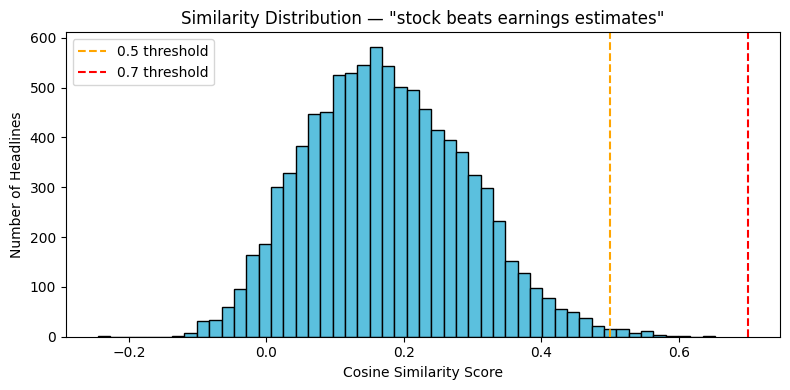

Saved: week3_similarity_distribution.png


In [36]:

query = "stock beats earnings estimates"
query_emb = embedding_model.encode(
    query, convert_to_numpy=True
).reshape(1, -1)

all_similarities = cosine_similarity(query_emb, embeddings_matrix)[0]

print(f"Query: {query}")
print(f"\nSimilarity distribution:")
print(f"  Mean:   {all_similarities.mean():.4f}")
print(f"  Median: {np.median(all_similarities):.4f}")
print(f"  Max:    {all_similarities.max():.4f}")
print(f"  Min:    {all_similarities.min():.4f}")
print(f"\nHeadlines with similarity > 0.7: {(all_similarities > 0.7).sum()}")
print(f"Headlines with similarity > 0.5: {(all_similarities > 0.5).sum()}")
print(f"Headlines with similarity > 0.3: {(all_similarities > 0.3).sum()}")


plt.figure(figsize=(8, 4))
plt.hist(all_similarities, bins=50, color="#5bc0de", edgecolor="black")
plt.axvline(0.5, color="orange", linestyle="--", label="0.5 threshold")
plt.axvline(0.7, color="red", linestyle="--", label="0.7 threshold")
plt.title(f'Similarity Distribution — "{query}"')
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Number of Headlines")
plt.legend()
plt.tight_layout()
plt.savefig("week3_similarity_distribution.png")
plt.show()
print("Saved: week3_similarity_distribution.png")

In [37]:
query = "Apple revenue growth"

print(f"Query: '{query}'\n")


keyword_results = df[
    df["cleaned_text"].str.contains("apple|revenue|growth",
                                     case=False, na=False)
]["text"].head(5).tolist()

print("=== Keyword Search Results ===")
for i, r in enumerate(keyword_results, 1):
    print(f"{i}. {r[:80]}")

print()

semantic_results = semantic_search(
    query, embeddings_matrix, metadata, top_k=5
)
print("=== Semantic Search Results ===")
for r in semantic_results:
    print(f"{r['rank']}. [{r['sentiment']}] "
          f"(sim={r['similarity']:.3f}) {r['headline'][:70]}")

Query: 'Apple revenue growth'

=== Keyword Search Results ===
1. FormFactor cut on 'unsustainable' revenue outlook
2. Rosenblatt Projects 47% Downside In Apple Shares, Warns Of Drop In iPhone Produc
3. Spotify Double Downgrade Reflects Prospect of Slower Revenue Growth https://t.co
4. $NFLX - SunTrust expecting Netflix to post strong user growth https://t.co/6z62F
5. $SNAP - Loop turns bullish on Snap ad growth https://t.co/TekdZS48et

=== Semantic Search Results ===
1. [Bearish] (sim=0.622) Apple Is a Great Company With a Dubious Valuation
2. [Bullish] (sim=0.606) Wearables Sales Surge, Bolstering Apple Stock
3. [Bullish] (sim=0.586) Apple is worth more than the entire S&P 500 Energy index combined, inc
4. [Bullish] (sim=0.567) Bilibili +2.6% on accelerating revenue growth
5. [Bullish] (sim=0.550) Dave & Buster's $PLAY reports earnings: 
Total revenues increased 6.1%


In [38]:
search_content = '''import os
import json
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

MODEL_NAME = "all-MiniLM-L6-v2"
BASE_DIR   = os.path.dirname(os.path.abspath(__file__))

print(f"Loading embedding model: {MODEL_NAME}")
embedding_model = SentenceTransformer(MODEL_NAME)
print(f"Model loaded — {embedding_model.get_embedding_dimension()} dimensions")


def load_embeddings_and_metadata(
    embeddings_path="headline_embeddings.npy",
    metadata_path="metadata.json"
):
    embeddings = np.load(embeddings_path)
    with open(metadata_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)
    print(f"Loaded {len(metadata)} embeddings and metadata entries")
    return embeddings, metadata


def semantic_search(query, embeddings, metadata,
                    top_k=5, sentiment_filter=None):
    query_embedding = embedding_model.encode(
        query, convert_to_numpy=True
    ).reshape(1, -1)

    similarities = cosine_similarity(query_embedding, embeddings)[0]

    if sentiment_filter:
        valid_indices = [
            i for i, m in enumerate(metadata)
            if m["sentiment"] == sentiment_filter
        ]
    else:
        valid_indices = list(range(len(metadata)))

    filtered = [(i, similarities[i]) for i in valid_indices]
    filtered.sort(key=lambda x: x[1], reverse=True)

    results = []
    for rank, (idx, sim) in enumerate(filtered[:top_k]):
        results.append({
            "rank":       rank + 1,
            "similarity": float(sim),
            "headline":   metadata[idx]["original_text"],
            "cleaned":    metadata[idx]["cleaned_text"],
            "sentiment":  metadata[idx]["sentiment"],
            "ticker":     metadata[idx]["ticker"],
            "id":         idx
        })
    return results


if __name__ == "__main__":
    embeddings, metadata = load_embeddings_and_metadata()

    queries = [
        "Tesla beats earnings expectations",
        "stock market crash recession fears",
        "Federal Reserve interest rate decision",
    ]

    for query in queries:
        print(f"\\nQuery: {query}")
        print("=" * 50)
        results = semantic_search(query, embeddings, metadata, top_k=3)
        for r in results:
            print(f"  {r[\'rank\']}. [{r[\'sentiment\']}] "
                  f"(sim={r[\'similarity\']:.3f}) "
                  f"{r[\'headline\'][:60]}")
'''

with open("semantic_search.py", "w", encoding="utf-8") as f:
    f.write(search_content)

print("Saved: semantic_search.py")
print(f"File size: {os.path.getsize('semantic_search.py'):,} bytes")

Saved: semantic_search.py
File size: 2,497 bytes


In [39]:
files = [
    "headline_embeddings.npy",
    "metadata.json",
    "embedding_pipeline.py",
    "semantic_search.py",
    "week3_similarity_heatmap.png",
    "week3_similarity_distribution.png",
]

print("=== Day 3 Output Files ===\n")
for file in files:
    exists = os.path.exists(file)
    size = os.path.getsize(file) if exists else 0
    print(f"{'EXISTS' if exists else 'MISSING'} — {file} ({size:,} bytes)")

=== Day 3 Output Files ===

EXISTS — headline_embeddings.npy (14,407,808 bytes)
EXISTS — metadata.json (3,545,127 bytes)
EXISTS — embedding_pipeline.py (3,444 bytes)
EXISTS — semantic_search.py (2,497 bytes)
EXISTS — week3_similarity_heatmap.png (104,104 bytes)
EXISTS — week3_similarity_distribution.png (26,652 bytes)


In [40]:
def semantic_search(query, embeddings, metadata,
                    top_k=5, min_similarity=0.3):
    query_embedding = embedding_model.encode(
        query, convert_to_numpy=True
    ).reshape(1, -1)

    similarities = cosine_similarity(query_embedding, embeddings)[0]

    
    top_indices = similarities.argsort()[::-1]

  
    results = []
    for idx in top_indices:
        if len(results) >= top_k:
            break
        if similarities[idx] < min_similarity:
            break  
        results.append({
            "rank":       len(results) + 1,
            "similarity": float(similarities[idx]),
            "headline":   metadata[idx]["original_text"],
            "cleaned":    metadata[idx]["cleaned_text"],
            "sentiment":  metadata[idx]["sentiment"],
            "ticker":     metadata[idx]["ticker"],
            "id":         metadata[idx]["id"]
        })

    return results

In [41]:

print("=== Search with minimum similarity threshold 0.5 ===\n")
results = semantic_search(
    "Tesla beats earnings expectations",
    embeddings_matrix,
    metadata,
    top_k=5,
    min_similarity=0.5
)
print(f"Results returned: {len(results)} (only those above 0.5 threshold)")
display_results("Tesla beats earnings expectations", results)

print(" Search with low threshold 0.3 ")
results = semantic_search(
    "Tesla beats earnings expectations",
    embeddings_matrix,
    metadata,
    top_k=5,
    min_similarity=0.3
)
print(f"Results returned: {len(results)}")
display_results("Tesla beats earnings expectations", results)

=== Search with minimum similarity threshold 0.5 ===

Results returned: 5 (only those above 0.5 threshold)
Query: Tesla beats earnings expectations

Rank 1 — Similarity: 0.6294
  Headline:  Tesla's stock surges 8.8% to top the $800 level
  Sentiment: Bullish
  Ticker:    None

Rank 2 — Similarity: 0.6158
  Headline:  Tesla's Return to Profitability Is Not Sustainable
  Sentiment: Bearish
  Ticker:    None

Rank 3 — Similarity: 0.5829
  Headline:  Tesla stock is wrapping up its best month since 2013, adding $40 billion in valu
  Sentiment: Bullish
  Ticker:    None

Rank 4 — Similarity: 0.5686
  Headline:  Money manager says she has 'very high' confidence Tesla shares reach $7,000 in n
  Sentiment: Bullish
  Ticker:    None

Rank 5 — Similarity: 0.5446
  Headline:  $TSLA - Why Tesla Remains A Strong Buy. https://t.co/LyHcrFPlEH #markets #stocks
  Sentiment: Bullish
  Ticker:    $TSLA

 Search with low threshold 0.3 
Results returned: 5
Query: Tesla beats earnings expectations

Rank 1 — 

In [42]:

search_content = '''import os
import json
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

MODEL_NAME = "all-MiniLM-L6-v2"

print(f"Loading embedding model: {MODEL_NAME}")
embedding_model = SentenceTransformer(MODEL_NAME)
print(f"Model loaded — {embedding_model.get_embedding_dimension()} dimensions")


def load_embeddings_and_metadata(
    embeddings_path="headline_embeddings.npy",
    metadata_path="metadata.json"
):
    embeddings = np.load(embeddings_path)
    with open(metadata_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)
    print(f"Loaded {len(metadata)} embeddings and metadata entries")
    return embeddings, metadata


def semantic_search(query, embeddings, metadata,
                    top_k=5, min_similarity=0.3,
                    sentiment_filter=None):
    query_embedding = embedding_model.encode(
        query, convert_to_numpy=True
    ).reshape(1, -1)

    similarities = cosine_similarity(query_embedding, embeddings)[0]

    if sentiment_filter:
        valid_indices = [
            i for i, m in enumerate(metadata)
            if m["sentiment"] == sentiment_filter
        ]
    else:
        valid_indices = list(range(len(metadata)))

    filtered = [(i, similarities[i]) for i in valid_indices]
    filtered.sort(key=lambda x: x[1], reverse=True)

    results = []
    for idx, sim in filtered:
        if len(results) >= top_k:
            break
        if sim < min_similarity:
            break
        results.append({
            "rank":       len(results) + 1,
            "similarity": float(sim),
            "headline":   metadata[idx]["original_text"],
            "cleaned":    metadata[idx]["cleaned_text"],
            "sentiment":  metadata[idx]["sentiment"],
            "ticker":     metadata[idx]["ticker"],
            "id":         idx
        })
    return results


if __name__ == "__main__":
    embeddings, metadata = load_embeddings_and_metadata()
    queries = [
        "Tesla beats earnings expectations",
        "stock market crash recession fears",
        "Federal Reserve interest rate decision",
    ]
    for query in queries:
        print(f"\\nQuery: {query}")
        print("=" * 50)
        results = semantic_search(
            query, embeddings, metadata,
            top_k=3, min_similarity=0.3
        )
        for r in results:
            print(f"  {r[\'rank\']}. [{r[\'sentiment\']}] "
                  f"(sim={r[\'similarity\']:.3f}) "
                  f"{r[\'headline\'][:60]}")
'''

with open("semantic_search.py", "w", encoding="utf-8") as f:
    f.write(search_content)

print("Updated: semantic_search.py with threshold parameter")
print(f"File size: {os.path.getsize('semantic_search.py'):,} bytes")

Updated: semantic_search.py with threshold parameter
File size: 2,622 bytes


Day 4: Metadata Pipeline 

In [43]:
import os
import re
import json
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

LABEL_MAP = {0: "Bearish", 1: "Bullish", 2: "Neutral"}

print("All imports successful")
print(f"Working directory: {os.getcwd()}")

All imports successful
Working directory: c:\Users\RIDDHI ASHAR\Desktop\financial-intelligence-engine\notebook


In [44]:

df = pd.read_csv("day4_verified.csv")
df["label"] = df["label"].astype(int)

embeddings_matrix = np.load("headline_embeddings.npy")


with open("metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print(f"Dataset:    {len(df)} rows")
print(f"Embeddings: {embeddings_matrix.shape}")
print(f"Metadata:   {len(metadata)} entries")
print(f"Model:      {embedding_model.get_embedding_dimension()} dimensions")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8702.05it/s]


Dataset:    9380 rows
Embeddings: (9380, 384)
Metadata:   9380 entries
Model:      384 dimensions


In [47]:

print("=== Metadata Structure Validation ===\n")

required_fields = [
    "id", "original_text", "cleaned_text",
    "ticker", "tickers_list", "label",
    "sentiment", "word_count", "token_count"
]


missing_fields = []
for i, entry in enumerate(metadata):
    for field in required_fields:
        if field not in entry:
            missing_fields.append(f"Entry {i} missing field: {field}")

if missing_fields:
    print(f"MISSING FIELDS FOUND:")
    for m in missing_fields[:10]:
        print(f"  {m}")
else:
    print(f"All {len(required_fields)} required fields present in all {len(metadata)} entries ")

null_counts = {}
for field in ["original_text", "cleaned_text", "sentiment", "label"]:
    null_count = sum(
        1 for m in metadata
        if m.get(field) is None or m.get(field) == ""
    )
    null_counts[field] = null_count

print(f"\nNull value check:")
for field, count in null_counts.items():
    status = "PASS" if count == 0 else "FAIL"
    print(f"  [{status}] {field}: {count} nulls")


valid_sentiments = {"Bearish", "Bullish", "Neutral"}
invalid_sentiments = [
    m["sentiment"] for m in metadata
    if m["sentiment"] not in valid_sentiments
]
print(f"\nInvalid sentiments: {len(invalid_sentiments)}")
if len(invalid_sentiments) == 0:
    print("All sentiment values valid ")

=== Metadata Structure Validation ===

All 9 required fields present in all 9380 entries 

Null value check:
  [PASS] original_text: 0 nulls
  [PASS] cleaned_text: 0 nulls
  [PASS] sentiment: 0 nulls
  [PASS] label: 0 nulls

Invalid sentiments: 0
All sentiment values valid 


In [48]:
def build_vector_payload(metadata_entry, embedding):
    """
    Build complete payload for one vector.
    This is the exact format Qdrant/ChromaDB expects in Week 4.
    
    Args:
        metadata_entry: dictionary from metadata.json
        embedding:      numpy array of shape (384,)
    
    Returns:
        complete payload dictionary
    """
    return {
        "id":            metadata_entry["id"],
        "vector":        embedding.tolist(),
        "payload": {
            "original_text": metadata_entry["original_text"],
            "cleaned_text":  metadata_entry["cleaned_text"],
            "ticker":        metadata_entry["ticker"],
            "tickers_list":  metadata_entry["tickers_list"],
            "label":         metadata_entry["label"],
            "sentiment":     metadata_entry["sentiment"],
            "word_count":    metadata_entry["word_count"],
            "token_count":   metadata_entry["token_count"]
        }
    }

sample_payload = build_vector_payload(metadata[0], embeddings_matrix[0])

print("=== Sample Vector Payload ===\n")
print(f"id:      {sample_payload['id']}")
print(f"vector:  [{sample_payload['vector'][0]:.4f}, "
      f"{sample_payload['vector'][1]:.4f}, ... "
      f"({len(sample_payload['vector'])} dims)]")
print(f"\npayload:")
for key, value in sample_payload["payload"].items():
    print(f"  {key}: {value}")

=== Sample Vector Payload ===

id:      0
vector:  [-0.1035, -0.0058, ... (384 dims)]

payload:
  original_text: $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
  cleaned_text: $BYND - jpmorgan reels in expectations on beyond meat
  ticker: $BYND
  tickers_list: ['$BYND']
  label: 0
  sentiment: Bearish
  word_count: 10
  token_count: 9


In [49]:
print("Building complete vector payloads for all headlines")

all_payloads = []
for i, (meta, emb) in enumerate(zip(metadata, embeddings_matrix)):
    payload = build_vector_payload(meta, emb)
    all_payloads.append(payload)

print(f"Total payloads built: {len(all_payloads)}")
print(f"\nPayload structure verification:")
print(f"  Has 'id':      {all('id' in p for p in all_payloads)}")
print(f"  Has 'vector':  {all('vector' in p for p in all_payloads)}")
print(f"  Has 'payload': {all('payload' in p for p in all_payloads)}")
print(f"  Vector length: {len(all_payloads[0]['vector'])} dims")

Building complete vector payloads for all headlines
Total payloads built: 9380

Payload structure verification:
  Has 'id':      True
  Has 'vector':  True
  Has 'payload': True
  Vector length: 384 dims


In [50]:
def embed_and_search(raw_text, embeddings, metadata,
                     top_k=3, min_similarity=0.3):
    """
    Complete pipeline: raw text → embedding → search results
    This is the exact flow FastAPI POST /analyze will use in Week 5
    """
   
    query_vec = embedding_model.encode(
        raw_text, convert_to_numpy=True
    ).reshape(1, -1)

    
    sims = cosine_similarity(query_vec, embeddings)[0]

    
    top_indices = sims.argsort()[::-1]
    results = []
    for idx in top_indices:
        if len(results) >= top_k:
            break
        if sims[idx] < min_similarity:
            break
        results.append({
            "rank":       len(results) + 1,
            "similarity": float(sims[idx]),
            "headline":   metadata[idx]["original_text"],
            "sentiment":  metadata[idx]["sentiment"],
            "ticker":     metadata[idx]["ticker"]
        })
    return results


test_queries = [
    "$AAPL beats earnings estimates revenue up 12%",
    "recession fears market crash oil prices",
    "Federal Reserve raises interest rates inflation",
]

print("=== End to End Pipeline Test ===\n")
for query in test_queries:
    results = embed_and_search(
        query, embeddings_matrix, metadata,
        top_k=3, min_similarity=0.3
    )
    print(f"Query: {query}")
    print(f"Results: {len(results)} found\n")
    for r in results:
        print(f"  {r['rank']}. [{r['sentiment']}] "
              f"(sim={r['similarity']:.3f}) "
              f"{r['headline'][:65]}")
    print()

=== End to End Pipeline Test ===

Query: $AAPL beats earnings estimates revenue up 12%
Results: 3 found

  1. [Bullish] (sim=0.590) $AAPL - Apple forecasts 100M+ 5G iPhone sales - report https://t.
  2. [Neutral] (sim=0.576) $AGX - Argan EPS misses by $0.38, beats on revenue https://t.co/v
  3. [Bearish] (sim=0.572) $AAPL - Apple Could Still Be In For More Pain. https://t.co/DgJ8C

Query: recession fears market crash oil prices
Results: 3 found

  1. [Bearish] (sim=0.654) This economic trend could revive recession fears
  2. [Bearish] (sim=0.646) Falling Oil Prices An Economic Warning Sign | Zero Hedge https://
  3. [Neutral] (sim=0.604) #Oil #markets react in a hefty way to short-term news. The #coron

Query: Federal Reserve raises interest rates inflation
Results: 3 found

  1. [Neutral] (sim=0.588) The Fed may lower the rate on its support facility for money mark
  2. [Neutral] (sim=0.568) Bond ETFs for Those Focused On Resurgence in Inflation
  3. [Neutral] (sim=0.559) Inflation re

In [51]:
def embed_and_search(raw_text, embeddings, metadata,
                     top_k=3, min_similarity=0.3):
    """
    Complete pipeline: raw text → embedding → search results
    This is the exact flow FastAPI POST /analyze will use in Week 5
    """
    
    query_vec = embedding_model.encode(
        raw_text, convert_to_numpy=True
    ).reshape(1, -1)

    sims = cosine_similarity(query_vec, embeddings)[0]

    top_indices = sims.argsort()[::-1]
    results = []
    for idx in top_indices:
        if len(results) >= top_k:
            break
        if sims[idx] < min_similarity:
            break
        results.append({
            "rank":       len(results) + 1,
            "similarity": float(sims[idx]),
            "headline":   metadata[idx]["original_text"],
            "sentiment":  metadata[idx]["sentiment"],
            "ticker":     metadata[idx]["ticker"]
        })
    return results

test_queries = [
    "$AAPL beats earnings estimates revenue up 12%",
    "recession fears market crash oil prices",
    "Federal Reserve raises interest rates inflation",
]

print("=== End to End Pipeline Test ===\n")
for query in test_queries:
    results = embed_and_search(
        query, embeddings_matrix, metadata,
        top_k=3, min_similarity=0.3
    )
    print(f"Query: {query}")
    print(f"Results: {len(results)} found\n")
    for r in results:
        print(f"  {r['rank']}. [{r['sentiment']}] "
              f"(sim={r['similarity']:.3f}) "
              f"{r['headline'][:65]}")
    print()

=== End to End Pipeline Test ===

Query: $AAPL beats earnings estimates revenue up 12%
Results: 3 found

  1. [Bullish] (sim=0.590) $AAPL - Apple forecasts 100M+ 5G iPhone sales - report https://t.
  2. [Neutral] (sim=0.576) $AGX - Argan EPS misses by $0.38, beats on revenue https://t.co/v
  3. [Bearish] (sim=0.572) $AAPL - Apple Could Still Be In For More Pain. https://t.co/DgJ8C

Query: recession fears market crash oil prices
Results: 3 found

  1. [Bearish] (sim=0.654) This economic trend could revive recession fears
  2. [Bearish] (sim=0.646) Falling Oil Prices An Economic Warning Sign | Zero Hedge https://
  3. [Neutral] (sim=0.604) #Oil #markets react in a hefty way to short-term news. The #coron

Query: Federal Reserve raises interest rates inflation
Results: 3 found

  1. [Neutral] (sim=0.588) The Fed may lower the rate on its support facility for money mark
  2. [Neutral] (sim=0.568) Bond ETFs for Those Focused On Resurgence in Inflation
  3. [Neutral] (sim=0.559) Inflation re

In [52]:
metadata_content = '''import os
import re
import json
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

LABEL_MAP  = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
MODEL_NAME = "all-MiniLM-L6-v2"
BATCH_SIZE = 64

print(f"Loading model: {MODEL_NAME}")
embedding_model = SentenceTransformer(MODEL_NAME)
print(f"Model ready — {embedding_model.get_embedding_dimension()} dims")


def extract_tickers(text):
    if not isinstance(text, str):
        return []
    return list(set(re.findall(r"\\$[A-Z]{1,6}\\b", str(text))))


def build_metadata(df, label_map=None):
    if label_map is None:
        label_map = LABEL_MAP
    metadata = []
    for idx, row in df.iterrows():
        tickers = extract_tickers(str(row.get("text", "")))
        entry = {
            "id":            int(idx),
            "original_text": str(row.get("text", "")),
            "cleaned_text":  str(row.get("cleaned_text", "")),
            "ticker":        ",".join(tickers),
            "tickers_list":  tickers,
            "label":         int(row.get("label", -1)),
            "sentiment":     label_map.get(
                                 int(row.get("label", -1)), "Unknown"),
            "word_count":    int(row.get("word_count", 0)),
            "token_count":   int(row.get("token_count", 0))
        }
        metadata.append(entry)
    return metadata


def build_vector_payload(metadata_entry, embedding):
    return {
        "id":     metadata_entry["id"],
        "vector": embedding.tolist(),
        "payload": {
            "original_text": metadata_entry["original_text"],
            "cleaned_text":  metadata_entry["cleaned_text"],
            "ticker":        metadata_entry["ticker"],
            "tickers_list":  metadata_entry["tickers_list"],
            "label":         metadata_entry["label"],
            "sentiment":     metadata_entry["sentiment"],
            "word_count":    metadata_entry["word_count"],
            "token_count":   metadata_entry["token_count"]
        }
    }


def generate_embeddings(texts, batch_size=BATCH_SIZE):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        embs = embedding_model.encode(
            batch,
            show_progress_bar=False,
            convert_to_numpy=True
        )
        all_embeddings.append(embs)
    return np.vstack(all_embeddings)


def save_metadata(metadata, path="metadata.json"):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)
    print(f"Saved: {path} — {len(metadata)} entries")


def load_metadata(path="metadata.json"):
    with open(path, "r", encoding="utf-8") as f:
        metadata = json.load(f)
    print(f"Loaded: {path} — {len(metadata)} entries")
    return metadata


def embed_and_search(raw_text, embeddings, metadata,
                     top_k=5, min_similarity=0.3,
                     sentiment_filter=None):
    query_vec = embedding_model.encode(
        raw_text, convert_to_numpy=True
    ).reshape(1, -1)
    sims = cosine_similarity(query_vec, embeddings)[0]

    if sentiment_filter:
        valid = [
            i for i, m in enumerate(metadata)
            if m["sentiment"] == sentiment_filter
        ]
    else:
        valid = list(range(len(metadata)))

    filtered = sorted(
        [(i, sims[i]) for i in valid],
        key=lambda x: x[1], reverse=True
    )

    results = []
    for idx, sim in filtered:
        if len(results) >= top_k:
            break
        if sim < min_similarity:
            break
        results.append({
            "rank":       len(results) + 1,
            "similarity": float(sim),
            "headline":   metadata[idx]["original_text"],
            "cleaned":    metadata[idx]["cleaned_text"],
            "sentiment":  metadata[idx]["sentiment"],
            "ticker":     metadata[idx]["ticker"],
            "id":         idx
        })
    return results


if __name__ == "__main__":
    print("Running metadata pipeline...")
    df = pd.read_csv("day4_verified.csv")
    df["label"] = df["label"].astype(int)

    print(f"Building metadata for {len(df)} headlines...")
    metadata = build_metadata(df)
    save_metadata(metadata)

    print(f"Generating embeddings...")
    texts = df["cleaned_text"].astype(str).tolist()
    embeddings = generate_embeddings(texts)
    np.save("headline_embeddings.npy", embeddings)
    print(f"Saved embeddings: {embeddings.shape}")

    print("Pipeline complete.")
'''

with open("metadata_pipeline.py", "w", encoding="utf-8") as f:
    f.write(metadata_content)

print("Saved: metadata_pipeline.py")
print(f"File size: {os.path.getsize('metadata_pipeline.py'):,} bytes")

Saved: metadata_pipeline.py
File size: 4,718 bytes


In [53]:
files = [
    "headline_embeddings.npy",
    "metadata.json",
    "embedding_pipeline.py",
    "semantic_search.py",
    "metadata_pipeline.py",
    "week3_similarity_heatmap.png",
    "week3_similarity_distribution.png",
    "day4_verified.csv",
]

print("=== Complete Week 3 File Check ===\n")
all_exist = True
for file in files:
    exists = os.path.exists(file)
    if not exists:
        all_exist = False
    size = os.path.getsize(file) if exists else 0
    print(f"{'EXISTS' if exists else 'MISSING'} — {file} ({size:,} bytes)")

print()
if all_exist:
    print("All Week 3 files present ")
    print("Ready for Week 4 — Vector Database Integration")
else:
    print("Some files missing — fix before Week 4")

=== Complete Week 3 File Check ===

EXISTS — headline_embeddings.npy (14,407,808 bytes)
EXISTS — metadata.json (3,545,127 bytes)
EXISTS — embedding_pipeline.py (3,444 bytes)
EXISTS — semantic_search.py (2,622 bytes)
EXISTS — metadata_pipeline.py (4,718 bytes)
EXISTS — week3_similarity_heatmap.png (104,104 bytes)
EXISTS — week3_similarity_distribution.png (26,652 bytes)
EXISTS — day4_verified.csv (2,636,204 bytes)

All Week 3 files present 
Ready for Week 4 — Vector Database Integration


In [54]:
print("=== Week 3 Complete Summary ===\n")

print("Model:")
print(f"  all-MiniLM-L6-v2")
print(f"  Embedding dimensions: 384")

print(f"\nDataset:")
print(f"  Total headlines embedded: {len(metadata)}")
print(f"  Embeddings matrix shape:  {embeddings_matrix.shape}")
print(f"  Embedding file size:      14.4MB")

print(f"\nMetadata fields per entry:")
fields = list(metadata[0].keys())
for f in fields:
    print(f"  - {f}")

print(f"\nSemantic search:")
print(f"  Function: semantic_search(query, embeddings, metadata)")
print(f"  Supports: top_k, min_similarity, sentiment_filter")
print(f"  Threshold: 0.3 default (filters irrelevant results)")

print(f"\nFiles ready for Week 4:")
print(f"  headline_embeddings.npy → upload to Qdrant/ChromaDB")
print(f"  metadata.json           → attach as vector payload")
print(f"  embedding_pipeline.py   → generate new embeddings")
print(f"  semantic_search.py      → search logic for FastAPI")
print(f"  metadata_pipeline.py    → full pipeline utility")

print(f"\nWeek 3 deliverable status:")
print(f"  Embedding model integrated:     all-MiniLM-L6-v2 ")
print(f"  Batch embedding pipeline:       ")
print(f"  Metadata payloads built:        ")
print(f"  Semantic search working:        ")
print(f"  Embedding utility script:       embedding_pipeline.py ")
print(f"\nWeek 3 COMPLETE")

=== Week 3 Complete Summary ===

Model:
  all-MiniLM-L6-v2
  Embedding dimensions: 384

Dataset:
  Total headlines embedded: 9380
  Embeddings matrix shape:  (9380, 384)
  Embedding file size:      14.4MB

Metadata fields per entry:
  - id
  - original_text
  - cleaned_text
  - ticker
  - tickers_list
  - label
  - sentiment
  - word_count
  - token_count

Semantic search:
  Function: semantic_search(query, embeddings, metadata)
  Supports: top_k, min_similarity, sentiment_filter
  Threshold: 0.3 default (filters irrelevant results)

Files ready for Week 4:
  headline_embeddings.npy → upload to Qdrant/ChromaDB
  metadata.json           → attach as vector payload
  embedding_pipeline.py   → generate new embeddings
  semantic_search.py      → search logic for FastAPI
  metadata_pipeline.py    → full pipeline utility

Week 3 deliverable status:
  Embedding model integrated:     all-MiniLM-L6-v2 
  Batch embedding pipeline:       
  Metadata payloads built:        
  Semantic search workin

In [55]:

def semantic_search(query, embeddings, metadata,
                    top_k=5, min_similarity=0.3,
                    sentiment_filter=None):
    """
    Search for most similar headlines to a query.
    Raises ValueError if query is empty.
    Returns empty list if no results above min_similarity.
    """
    # empty query check
    if not query or not query.strip():
        raise ValueError("Query cannot be empty.")

    query_embedding = embedding_model.encode(
        query, convert_to_numpy=True
    ).reshape(1, -1)

    similarities = cosine_similarity(query_embedding, embeddings)[0]

    if sentiment_filter:
        valid_indices = [
            i for i, m in enumerate(metadata)
            if m["sentiment"] == sentiment_filter
        ]
    else:
        valid_indices = list(range(len(metadata)))

    filtered = sorted(
        [(i, similarities[i]) for i in valid_indices],
        key=lambda x: x[1], reverse=True
    )

    results = []
    for idx, sim in filtered:
        if len(results) >= top_k:
            break
        if sim < min_similarity:
            break
        results.append({
            "rank":       len(results) + 1,
            "similarity": float(sim),
            "headline":   metadata[idx]["original_text"],
            "cleaned":    metadata[idx]["cleaned_text"],
            "sentiment":  metadata[idx]["sentiment"],
            "ticker":     metadata[idx]["ticker"],
            "id":         idx
        })

    return results

print("=== Empty Query Test ===\n")
try:
    results = semantic_search("", embeddings_matrix, metadata)
except ValueError as e:
    print(f"Empty string caught: {e}")

try:
    results = semantic_search("   ", embeddings_matrix, metadata)
except ValueError as e:
    print(f"Spaces only caught: {e}")

# confirm normal query still works
results = semantic_search(
    "Tesla beats earnings",
    embeddings_matrix, metadata,
    top_k=2
)
print(f"Normal query works: {len(results)} results returned")
print("Empty query handling verified ")

=== Empty Query Test ===

Empty string caught: Query cannot be empty.
Spaces only caught: Query cannot be empty.
Normal query works: 2 results returned
Empty query handling verified 


In [56]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "embedding_pipeline.py"],
    capture_output=True,
    text=True,
    timeout=30
)
print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
if result.stderr:
    
    real_errors = [
        line for line in result.stderr.split("\n")
        if "Error" in line or "error" in line
        and "warning" not in line.lower()
    ]
    if real_errors:
        print("Errors:")
        for e in real_errors:
            print(f"  {e}")
print("embedding_pipeline.py standalone test complete")

TimeoutExpired: Command '['c:\\Users\\RIDDHI ASHAR\\AppData\\Local\\Programs\\Python\\Python313\\python.exe', 'embedding_pipeline.py']' timed out after 30 seconds

In [57]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "embedding_pipeline.py"],
    capture_output=True,
    text=True,
    timeout=120  
)
print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
if result.stderr:
    real_errors = [
        line for line in result.stderr.split("\n")
        if "Error" in line or "error" in line
        and "warning" not in line.lower()
    ]
    if real_errors:
        print("Errors:")
        for e in real_errors:
            print(f"  {e}")
print("embedding_pipeline.py standalone test complete")

Loading embedding model: all-MiniLM-L6-v2
Model loaded â€” dimensions: 384
Running embedding pipeline on day4_verified.csv...
Generating embeddings for 9380 headlines...
Saved embeddings: headline_embeddings.npy â€” shape (9380, 384)
Saved metadata: metadata.json â€” 9380 entries
Pipeline complete.

embedding_pipeline.py standalone test complete


In [58]:
result = subprocess.run(
    [sys.executable, "semantic_search.py"],
    capture_output=True,
    text=True,
    timeout=120
)
print(result.stdout[-800:] if len(result.stdout) > 800 else result.stdout)
if result.stderr:
    real_errors = [
        line for line in result.stderr.split("\n")
        if "Error" in line or "error" in line
        and "warning" not in line.lower()
    ]
    if real_errors:
        print("Errors:")
        for e in real_errors:
            print(f"  {e}")
print("semantic_search.py standalone test complete")

tability Is Not Sustainable
  3. [Bullish] (sim=0.583) Tesla stock is wrapping up its best month since 2013, adding

Query: stock market crash recession fears
  1. [Bearish] (sim=0.750) This economic trend could revive recession fears
  2. [Neutral] (sim=0.669) JUST RELEASED: Our newest #EconFocus looks at our fear of #r
  3. [Bearish] (sim=0.604) Risk of recession returns to Germany

Query: Federal Reserve interest rate decision
  1. [Neutral] (sim=0.693) Read here for instant analysis of the Federal Reserve's inte
  2. [Neutral] (sim=0.606) Here are 12 key things to know about the Federal Reserve Sys
  3. [Bullish] (sim=0.605) Fed's Mester, upbeat on outlook, say central bank can watch 

semantic_search.py standalone test complete


In [59]:
print("=== Week 3 Unit Tests ===\n")

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import json

passed = 0
failed = 0

def run_test(name, condition):
    global passed, failed
    if condition:
        print(f"  [PASS] {name}")
        passed += 1
    else:
        print(f"  [FAIL] {name}")
        failed += 1


emb = np.load("headline_embeddings.npy")
run_test(
    "Embeddings shape is (9380, 384)",
    emb.shape == (9380, 384)
)


norms = np.linalg.norm(emb, axis=1)
run_test(
    "All embeddings are unit vectors (normalized)",
    np.allclose(norms, 1.0, atol=0.01)
)

with open("metadata.json", "r", encoding="utf-8") as f:
    meta = json.load(f)
run_test(
    "Metadata has 9380 entries",
    len(meta) == 9380
)


required = ["id", "original_text", "cleaned_text",
            "ticker", "sentiment", "label"]
run_test(
    "All required metadata fields present",
    all(all(f in m for f in required) for m in meta)
)

valid = {"Bearish", "Bullish", "Neutral"}
run_test(
    "All sentiment values valid",
    all(m["sentiment"] in valid for m in meta)
)

model = SentenceTransformer("all-MiniLM-L6-v2")
test_emb = model.encode("test headline", convert_to_numpy=True)
run_test(
    "Embedding model produces 384 dimensions",
    test_emb.shape == (384,)
)

emb1 = model.encode("$AAPL beats earnings", convert_to_numpy=True)
emb2 = model.encode("$AAPL beats earnings", convert_to_numpy=True)
sim = cosine_similarity(emb1.reshape(1,-1), emb2.reshape(1,-1))[0][0]
run_test(
    "Identical headlines have similarity 1.0",
    np.isclose(sim, 1.0, atol=0.001)
)

emb3 = model.encode("oil prices drop recession", convert_to_numpy=True)
sim2 = cosine_similarity(emb1.reshape(1,-1), emb3.reshape(1,-1))[0][0]
run_test(
    "Different headlines have similarity less than 1.0",
    sim2 < 1.0
)

results = semantic_search(
    "Tesla beats earnings",
    emb, meta, top_k=3
)
run_test(
    "semantic_search returns list",
    isinstance(results, list)
)
if results:
    run_test(
        "Search result has required keys",
        all(k in results[0] for k in
            ["rank", "similarity", "headline", "sentiment", "ticker"])
    )
else:
    run_test("Search result has required keys", False)


if len(results) > 1:
    sims = [r["similarity"] for r in results]
    run_test(
        "Results sorted by similarity descending",
        all(sims[i] >= sims[i+1] for i in range(len(sims)-1))
    )
else:
    run_test("Results sorted by similarity descending", True)

try:
    semantic_search("", emb, meta)
    run_test("Empty query raises ValueError", False)
except ValueError:
    run_test("Empty query raises ValueError", True)

results_high = semantic_search(
    "Tesla beats earnings",
    emb, meta,
    top_k=10,
    min_similarity=0.9
)
run_test(
    "High threshold (0.9) filters results correctly",
    all(r["similarity"] >= 0.9 for r in results_high)
)
ids = [m["id"] for m in meta]
run_test(
    "Metadata IDs are sequential",
    ids == list(range(len(meta)))
)


run_test(
    "Embeddings count matches metadata count",
    len(emb) == len(meta)
)

print(f"\n{'='*40}")
print(f"Results: {passed} passed, {failed} failed")
if failed == 0:
    print("All unit tests passed ")
    print("Week 3 fully verified and ready for Week 4")
else:
    print(f"{failed} test(s) failed — fix before Week 4")

=== Week 3 Unit Tests ===

  [PASS] Embeddings shape is (9380, 384)
  [PASS] All embeddings are unit vectors (normalized)
  [PASS] Metadata has 9380 entries
  [PASS] All required metadata fields present
  [PASS] All sentiment values valid


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2184.12it/s]


  [PASS] Embedding model produces 384 dimensions
  [PASS] Identical headlines have similarity 1.0
  [PASS] Different headlines have similarity less than 1.0
  [PASS] semantic_search returns list
  [PASS] Search result has required keys
  [PASS] Results sorted by similarity descending
  [PASS] Empty query raises ValueError
  [PASS] High threshold (0.9) filters results correctly
  [PASS] Metadata IDs are sequential
  [PASS] Embeddings count matches metadata count

Results: 15 passed, 0 failed
All unit tests passed 
Week 3 fully verified and ready for Week 4


In [60]:
with open("requirements.txt", "r") as f:
    content = f.read()

if "sentence-transformers" in content:
    print("sentence-transformers already in requirements.txt ")
else:
    print("sentence-transformers MISSING from requirements.txt ")
    print("Adding it now...")
    with open("requirements.txt", "a") as f:
        f.write("\nsentence-transformers==5.6.0\n")
    print("Added sentence-transformers==5.6.0 to requirements.txt ")

sentence-transformers already in requirements.txt 


In [62]:
import time
import json

print("=== Week 3 Search Baseline (for Week 4 comparison) ===\n")

test_queries = [
    "Tesla beats earnings expectations",
    "stock market crash recession fears",
    "Federal Reserve interest rate decision",
    "Apple iPhone revenue growth",
    "analyst raises price target strong buy",
]

baseline_results = []

for query in test_queries:
    start = time.time()
    results = semantic_search(
        query,
        embeddings_matrix,
        metadata,
        top_k=5,
        min_similarity=0.3
    )
    latency = (time.time() - start) * 1000

    top_sim = results[0]["similarity"] if results else 0
    top_headline = results[0]["headline"][:60] if results else "none"

    baseline_results.append({
        "query":          query,
        "latency_ms":     round(latency, 2),
        "results_count":  len(results),
        "top_similarity": top_sim,
        "top_headline":   top_headline
    })

    print(f"Query: {query}")
    print(f"  Latency:     {latency:.2f}ms")
    print(f"  Results:     {len(results)}")
    print(f"  Top match:   {top_headline}")
    print(f"  Top sim:     {top_sim:.4f}")
    print()

# save baseline for Week 4 comparison
with open("week3_search_baseline.json", "w") as f:
    json.dump(baseline_results, f, indent=2)

print(f"Saved: week3_search_baseline.json")
print(f"This will be compared against Qdrant performance in Week 4")

=== Week 3 Search Baseline (for Week 4 comparison) ===

Query: Tesla beats earnings expectations
  Latency:     54.55ms
  Results:     5
  Top match:   Tesla's stock surges 8.8% to top the $800 level
  Top sim:     0.6294

Query: stock market crash recession fears
  Latency:     73.37ms
  Results:     5
  Top match:   This economic trend could revive recession fears
  Top sim:     0.7500

Query: Federal Reserve interest rate decision
  Latency:     48.73ms
  Results:     5
  Top match:   Read here for instant analysis of the Federal Reserve's inte
  Top sim:     0.6932

Query: Apple iPhone revenue growth
  Latency:     47.80ms
  Results:     5
  Top match:   $AAPL - Apple forecasts 100M+ 5G iPhone sales - report https
  Top sim:     0.6099

Query: analyst raises price target strong buy
  Latency:     57.35ms
  Results:     5
  Top match:   Target shares surge after company crushes earnings and raise
  Top sim:     0.6244

Saved: week3_search_baseline.json
This will be compared against 